In [11]:
# import libraries 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
#reading the different excel sheets.
df_1 = pd.read_excel('/Users/nataliastroher/NatisProjects/manufacturing_downtime/Manufacturing_Line_Productivity.xlsx', sheet_name='Line productivity')
df_2 = pd.read_excel('/Users/nataliastroher/NatisProjects/manufacturing_downtime/Manufacturing_Line_Productivity.xlsx', sheet_name='Products')
df_3 = pd.read_excel('/Users/nataliastroher/NatisProjects/manufacturing_downtime/Manufacturing_Line_Productivity.xlsx', sheet_name='Downtime factors')
df_4 = pd.read_excel('/Users/nataliastroher/NatisProjects/manufacturing_downtime/Manufacturing_Line_Productivity.xlsx', sheet_name='Line downtime')


In [32]:
# reading the dataframes to check the correctness of the data and columns.
#df_1.head()
#df_2.head()
#df_3.head()
#df_4.head()

In [33]:
# Providing new meaningful column names to df_4 (line downtime); instead of Factors 1 to 12, the actual names, taken out of df_3.
df_4_clean = df_4.copy()

df_4_clean.columns = df_4_clean.iloc[0]
df_4_clean = df_4_clean.iloc[1:].reset_index(drop=True)

# 2. Faktor-Mapping aus df_3 erstellen
factor_map = dict(zip(df_3["Factor"], df_3["Description"]))

# 3. Spaltennamen vorbereiten und umbenennen
new_columns = []

for col in df_4_clean.columns:
    # Batch-Spalte behalten
    if col == "Batch":
        new_columns.append("Batch")
    else:
        # aus 1.0 -> 1 machen
        factor_number = int(float(col))
        new_columns.append(factor_map[factor_number])

df_4_clean.columns = new_columns

# 4. Werte numerisch machen, außer Batch
for col in df_4_clean.columns:
    if col != "Batch":
        df_4_clean[col] = pd.to_numeric(df_4_clean[col], errors="coerce")

df_4_clean.head()

,Batch,Emergency stop,Batch change,Labeling error,Inventory shortage,Product spill,Machine adjustment,Machine failure,Batch coding error,Conveyor belt jam,Calibration error,Label switch,Other
0,422111,NaN,60.0,NaN,NaN,NaN,NaN,15.0,NaN,NaN,NaN,NaN,NaN
1,422112,NaN,20.0,NaN,NaN,NaN,NaN,NaN,20.0,NaN,NaN,NaN,NaN
2,422113,NaN,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,422114,NaN,NaN,NaN,25.0,NaN,15.0,NaN,NaN,NaN,NaN,NaN,NaN
4,422115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.0,NaN,NaN


In [34]:
#downtime per batch
df_4_clean["Total_Downtime"] = df_4_clean.drop(columns="Batch").sum(axis=1) # I drop the column "Batch" for calculating only the rest of columns, containing downtime values.
#df_4_clean.head()

In [35]:
# adding the total downtime per batch to the main dataframe.
df_1['Total_Downtime'] = df_4_clean['Total_Downtime']

In [ ]:
# Transform from wide to long - I have a new df containing in one column the batch numbers repeated as many times as downtime factors, 
# the name of the factor in another column and the duration in minutes in a third one.
df_long = df_4_clean.melt(
    id_vars="Batch",
    var_name="Factor",
    value_name="Minutes"
)
#df_long.head()

,Batch,Factor,Minutes
0,422111,Emergency stop,NaN
1,422112,Emergency stop,NaN
2,422113,Emergency stop,NaN
3,422114,Emergency stop,NaN
4,422115,Emergency stop,NaN


In [38]:
# now I add as new column the 'Operator Error' Yes/No, from df_3 
df_long = df_long.merge(
    df_3[['Description', 'Operator Error']], 
    left_on='Factor',       # column in df1
    right_on='Description', # matching column in df2
    how='left'
).drop(columns='Description')

In [ ]:
#df_long.head()

,Batch,Factor,Minutes,Operator Error
0,422111,Emergency stop,NaN,No
1,422112,Emergency stop,NaN,No
2,422113,Emergency stop,NaN,No
3,422114,Emergency stop,NaN,No
4,422115,Emergency stop,NaN,No


In [40]:
# Group by Batch + Operator Error
df_result = df_long.groupby(["Batch", "Operator Error"])["Minutes"].sum().unstack(fill_value=0).reset_index()
df_result.columns.name = None
# Flatten the MultiIndex columns first
df_result.columns = ["Batch", "Human_Error_Minutes", "Machine_Error_Minutes"]



In [41]:

# Merge into main dataset
df_1 = df_1.merge(df_result, on="Batch", how="left")

#df_1.head()

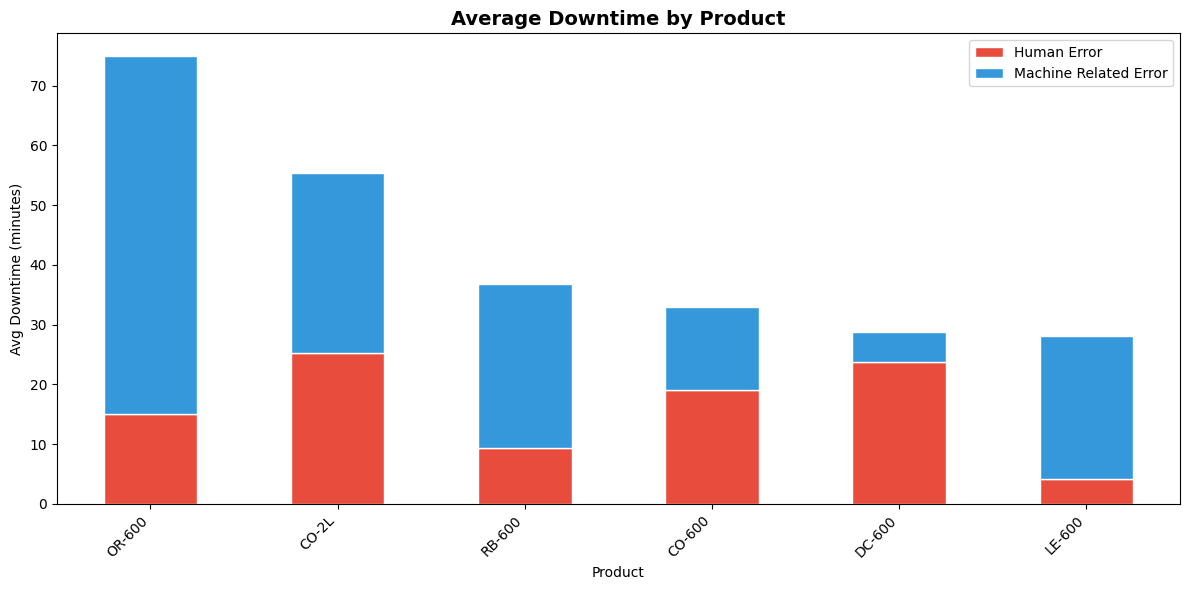

In [42]:
# Group by Product and calculate average downtime
df_plot = df_1.groupby("Product")[["Human_Error_Minutes", "Machine_Error_Minutes"]].mean().reset_index()
df_plot['Total'] = df_plot['Human_Error_Minutes'] + df_plot['Machine_Error_Minutes']
df_plot = df_plot.sort_values('Total', ascending=False).drop(columns='Total')

# 3. Plot stacked bar chart
ax = df_plot.set_index("Product")[["Human_Error_Minutes", "Machine_Error_Minutes"]].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=["#e74c3c", "#3498db"],  # red for human, blue for machine
    edgecolor="white"
)

plt.title("Average Downtime by Product", fontsize=14, fontweight="bold")
plt.xlabel("Product")
plt.ylabel("Avg Downtime (minutes)")
plt.xticks(rotation=45, ha="right")
plt.legend(["Human Error", "Machine Related Error"])
plt.tight_layout()
plt.show()

In [23]:
df_plot["Human_Pct"] = df_plot["Human_Error_Minutes"] / (df_plot["Human_Error_Minutes"] + df_plot["Machine_Error_Minutes"]) * 100
df_plot["Machine_Pct"] = 100 - df_plot["Human_Pct"]

print(df_plot[["Product", "Human_Pct", "Machine_Pct"]].sort_values("Human_Pct", ascending=False))

  Product  Human_Pct  Machine_Pct
2  DC-600  82.608696    17.391304
1  CO-600  57.894737    42.105263
0   CO-2L  45.487365    54.512635
5  RB-600  25.193798    74.806202
4  OR-600  20.000000    80.000000
3  LE-600  14.792899    85.207101


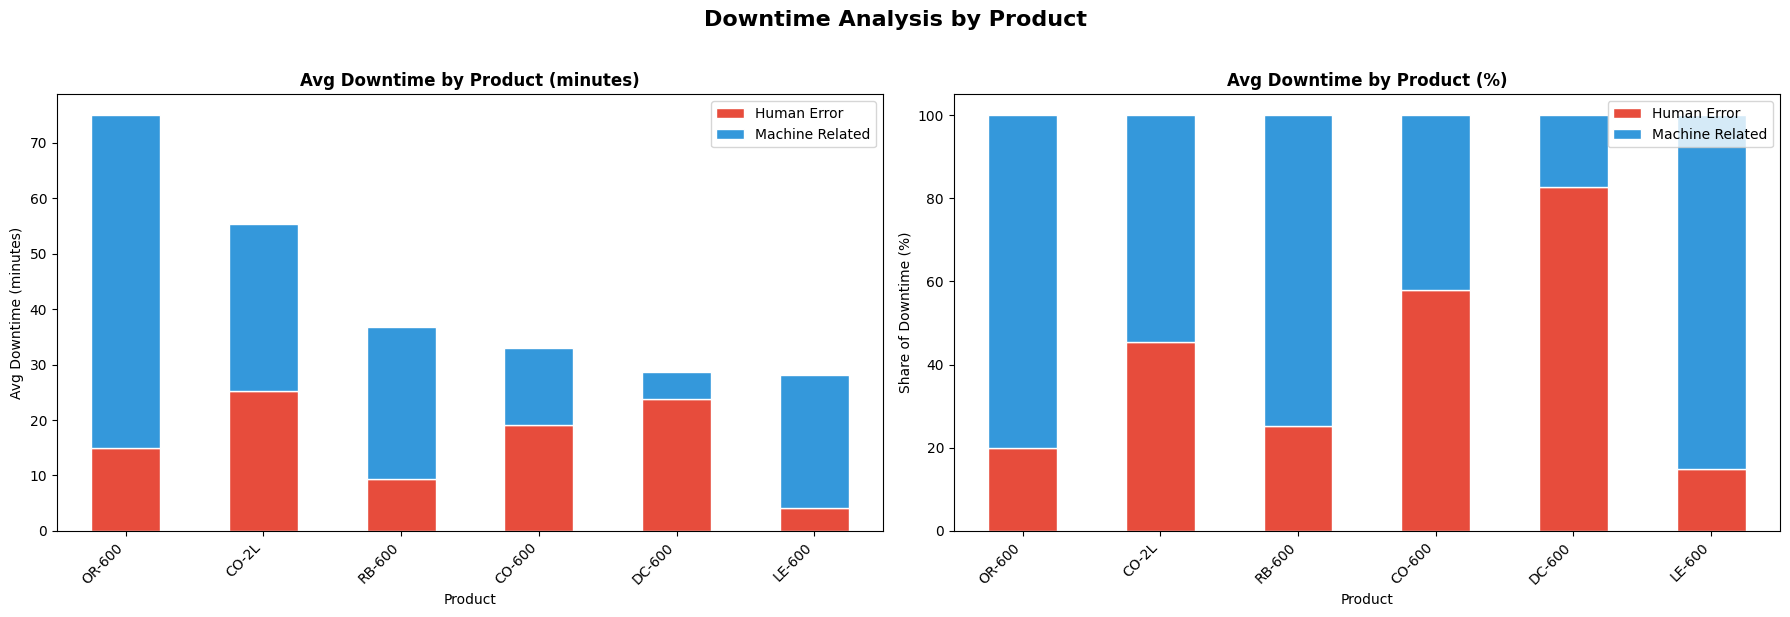

In [24]:
# Prepare absolute data (already have this)
df_abs = df_plot.copy()

# Prepare percentage data
df_pct = df_plot.copy()
df_pct["Human_Error_Minutes"] = df_plot["Human_Error_Minutes"] / (df_plot["Human_Error_Minutes"] + df_plot["Machine_Error_Minutes"]) * 100
df_pct["Machine_Error_Minutes"] = 100 - df_pct["Human_Error_Minutes"]

# Plot side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Left: absolute minutes
df_abs.set_index("Product")[["Human_Error_Minutes", "Machine_Error_Minutes"]].plot(
    kind="bar", stacked=True, ax=ax1,
    color=["#e74c3c", "#3498db"], edgecolor="white"
)
ax1.set_title("Avg Downtime by Product (minutes)", fontweight="bold")
ax1.set_xlabel("Product")
ax1.set_ylabel("Avg Downtime (minutes)")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
ax1.legend(["Human Error", "Machine Related"])

# Right: percentage
df_pct.set_index("Product")[["Human_Error_Minutes", "Machine_Error_Minutes"]].plot(
    kind="bar", stacked=True, ax=ax2,
    color=["#e74c3c", "#3498db"], edgecolor="white"
)
ax2.set_title("Avg Downtime by Product (%)", fontweight="bold")
ax2.set_xlabel("Product")
ax2.set_ylabel("Share of Downtime (%)")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right")
ax2.legend(["Human Error", "Machine Related"])

plt.suptitle("Downtime Analysis by Product", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [25]:
#converting Start and End Time to time format: (one of the rows was not in the right format, this function checks and if necessary converts.)
import datetime

def to_time(x):
    if isinstance(x, datetime.datetime):
        return x.time()
    return x

df_1['Start Time'] = df_1['Start Time'].apply(to_time)
df_1['End Time'] = df_1['End Time'].apply(to_time)

In [26]:

#calculating the minutes for a batch, taking into consideration the downtimes.
df_1['Batch_minutes'] = df_1.apply(lambda row: 
    (row['End Time'].hour * 60 + row['End Time'].minute) - 
    (row['Start Time'].hour * 60 + row['Start Time'].minute) + 
    (1440 if row['End Time'] < row['Start Time'] else 0), axis=1)

In [27]:
#actual process time, if we would not take into consideration the downtime. 
df_1['Machine_Minutes'] = df_1['Batch_minutes'] - df_1['Total_Downtime']

In [28]:
# Machine Minutes / Batch Minutes
df_1['efficiency'] = df_1['Machine_Minutes']/df_1['Batch_minutes']*100

# or the inverse, downtime rate
df_1['downtime_rate'] = df_1['Total_Downtime'] / df_1['Batch_minutes'] * 100

# group by line and product to compare
df_1_agg= df_1.groupby(['Product']).agg(
    avg_efficiency=('efficiency', 'mean'),
    avg_downtime_rate=('downtime_rate', 'mean'),
    total_downtime=('Total_Downtime', 'sum'),
    total_process_time=('Machine_Minutes', 'sum')
).round(2)

In [29]:

df_1_agg = df_1_agg.sort_values('avg_efficiency', ascending=False).reset_index()
df_1_agg.head(10)


,Product,avg_efficiency,avg_downtime_rate,total_downtime,total_process_time
0,DC-600,71.67,28.33,115.0,240.0
1,LE-600,71.00,29.00,169.0,360.0
2,CO-600,67.34,32.66,494.0,900.0
3,CO-2L,66.12,33.88,277.0,490.0
4,RB-600,64.45,35.55,258.0,420.0
5,OR-600,44.44,55.56,75.0,60.0


/var/folders/3y/f9tt7gts7qs7mbxh1h2q8x8h0000gn/T/ipykernel_21753/1215378646.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_1_agg, x="Product", y="avg_efficiency", palette="Blues_d")


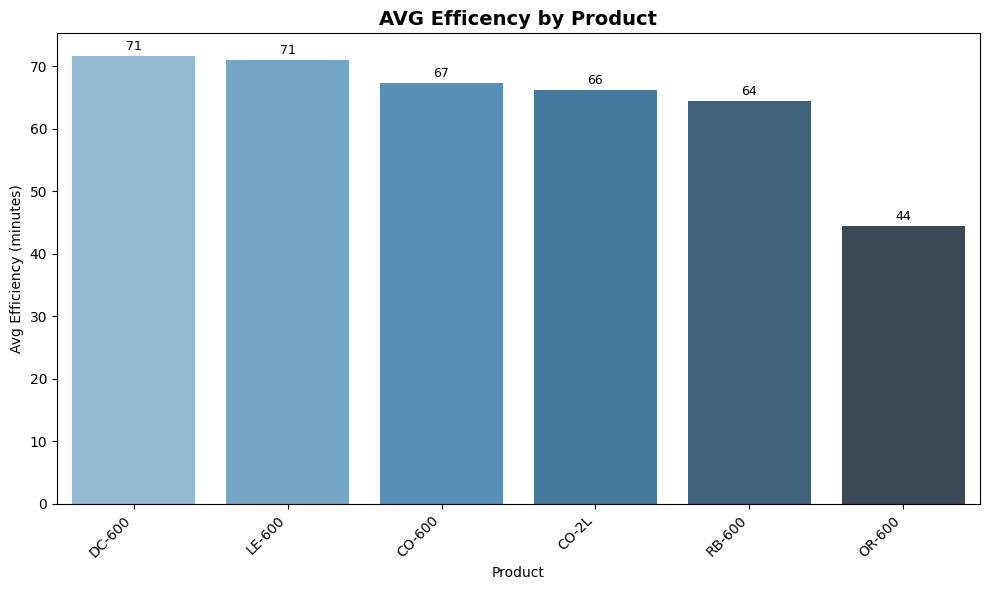

In [30]:
# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_1_agg, x="Product", y="avg_efficiency", palette="Blues_d")

# Labels
plt.title("AVG Efficency by Product", fontsize=14, fontweight="bold")
plt.xlabel("Product")
plt.ylabel("Avg Efficiency (minutes)")
plt.xticks(rotation=45, ha="right")

# Add value labels on top of each bar
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{int(bar.get_height())}",
        ha="center", va="bottom", fontsize=9
    )

plt.tight_layout()
plt.show()

3- Leading factors for downtime

Frequency — which happens more often?
Severity — which causes longer downtime per incident?